#### Churn Predictor using sklearn's `RandomForestClassifier`

Tree ensemble.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
from utils.helpers import encode_data, f1_score
from utils.consts import n_estimators_list, min_samples_split_list, max_depth_list

df = encode_data(pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv"))

In [12]:
features = df.drop(['Churn', "customerID"], axis=1)
target = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

min_samples_split: 2, max_depth: 1, n_estimators: 10 => Train Accuracy: 0.7345, Test Accuracy: 0.7353
min_samples_split: 2, max_depth: 1, n_estimators: 50 => Train Accuracy: 0.7345, Test Accuracy: 0.7353
min_samples_split: 2, max_depth: 1, n_estimators: 100 => Train Accuracy: 0.7345, Test Accuracy: 0.7353
min_samples_split: 2, max_depth: 1, n_estimators: 200 => Train Accuracy: 0.7345, Test Accuracy: 0.7353
min_samples_split: 2, max_depth: 1, n_estimators: 500 => Train Accuracy: 0.7345, Test Accuracy: 0.7353
min_samples_split: 2, max_depth: 2, n_estimators: 10 => Train Accuracy: 0.7606, Test Accuracy: 0.7644
min_samples_split: 2, max_depth: 2, n_estimators: 50 => Train Accuracy: 0.7737, Test Accuracy: 0.7821
min_samples_split: 2, max_depth: 2, n_estimators: 100 => Train Accuracy: 0.7733, Test Accuracy: 0.7842
min_samples_split: 2, max_depth: 2, n_estimators: 200 => Train Accuracy: 0.7629, Test Accuracy: 0.7736
min_samples_split: 2, max_depth: 2, n_estimators: 500 => Train Accuracy: 0.76

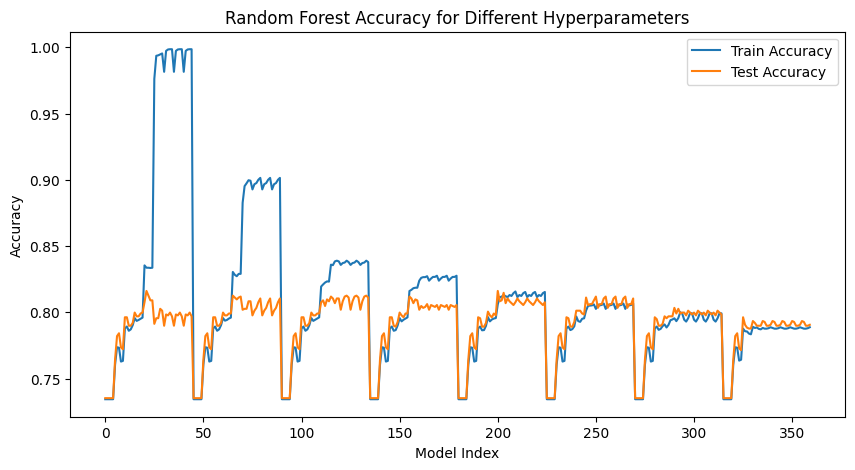

In [ ]:
accuracy_train_list = []
accuracy_test_list = []

for min_sample in min_samples_split_list:
    for max_depth in max_depth_list:
        for n_estimator in n_estimators_list:
            model = RandomForestClassifier(min_samples_split=min_sample, max_depth=max_depth, n_estimators=n_estimator, random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)
            accuracy_train = accuracy_score(y_train, y_train_pred)
            accuracy_test = accuracy_score(y_test, y_test_pred)
            accuracy_train_list.append(accuracy_train)
            accuracy_test_list.append(accuracy_test)
            print(f"min_samples_split: {min_sample}, max_depth: {max_depth}, n_estimators: {n_estimator} => Train Accuracy: {accuracy_train:.4f}, Test Accuracy: {accuracy_test:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(accuracy_train_list, label='Train Accuracy')
plt.plot(accuracy_test_list, label='Test Accuracy')
plt.xlabel('Model Index')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy for Different Hyperparameters')
plt.legend()
plt.show()


min_samples_split: 2 => Train Accuracy: 0.9984, Test Accuracy: 0.7977
min_samples_split: 10 => Train Accuracy: 0.8976, Test Accuracy: 0.8034
min_samples_split: 30 => Train Accuracy: 0.8376, Test Accuracy: 0.8119
min_samples_split: 50 => Train Accuracy: 0.8268, Test Accuracy: 0.8048
min_samples_split: 100 => Train Accuracy: 0.8124, Test Accuracy: 0.8070
min_samples_split: 200 => Train Accuracy: 0.8053, Test Accuracy: 0.8062
min_samples_split: 300 => Train Accuracy: 0.7955, Test Accuracy: 0.8013
min_samples_split: 700 => Train Accuracy: 0.7877, Test Accuracy: 0.7899


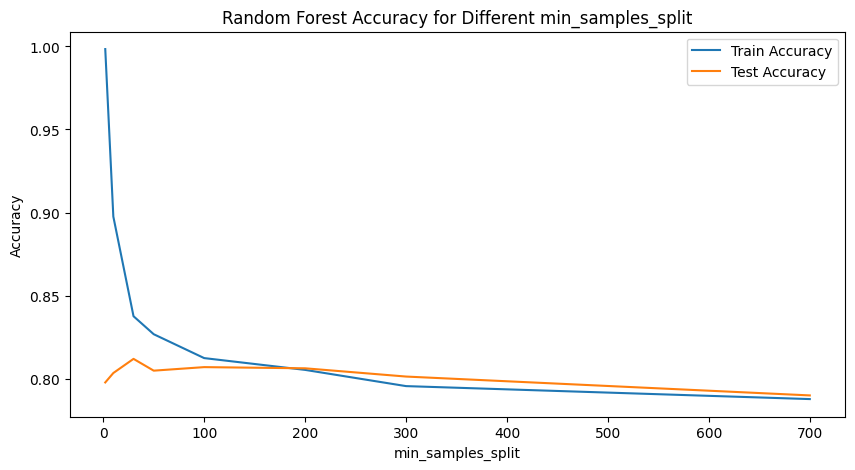

In [19]:
accuracy_train_list = []
accuracy_test_list = []

for min_samples_split in min_samples_split_list:
    model = RandomForestClassifier(min_samples_split=min_samples_split, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_test = accuracy_score(y_test, y_test_pred)
    accuracy_train_list.append(accuracy_train)
    accuracy_test_list.append(accuracy_test)
    print(f"min_samples_split: {min_samples_split} => Train Accuracy: {accuracy_train:.4f}, Test Accuracy: {accuracy_test:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(min_samples_split_list, accuracy_train_list, label='Train Accuracy')
plt.plot(min_samples_split_list, accuracy_test_list, label='Test Accuracy')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy for Different min_samples_split')
plt.legend()
plt.show()

max_depth: 1 => Train Accuracy: 0.7345, Test Accuracy: 0.7353
max_depth: 2 => Train Accuracy: 0.7733, Test Accuracy: 0.7842
max_depth: 3 => Train Accuracy: 0.7861, Test Accuracy: 0.7899
max_depth: 4 => Train Accuracy: 0.7943, Test Accuracy: 0.7970
max_depth: 8 => Train Accuracy: 0.8337, Test Accuracy: 0.8126
max_depth: 16 => Train Accuracy: 0.9940, Test Accuracy: 0.7956
max_depth: 32 => Train Accuracy: 0.9984, Test Accuracy: 0.7977
max_depth: 64 => Train Accuracy: 0.9984, Test Accuracy: 0.7977
max_depth: None => Train Accuracy: 0.9984, Test Accuracy: 0.7977


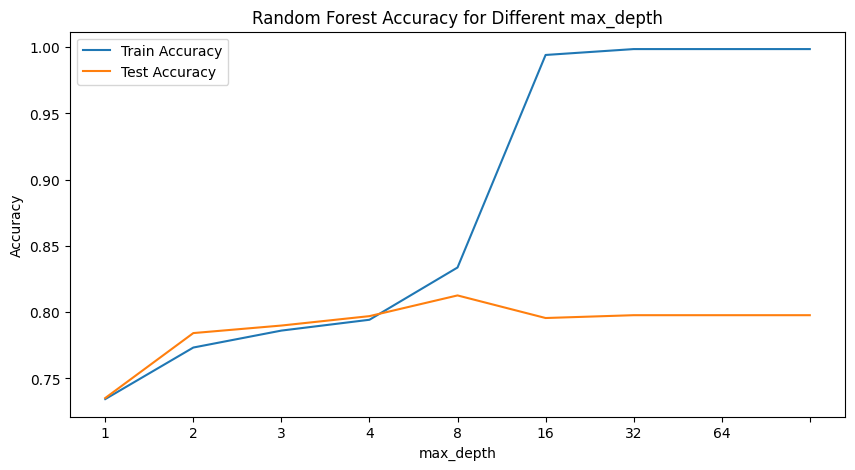

In [26]:
accuracy_train_list = []
accuracy_test_list = []

for max_depth in max_depth_list:
    model = RandomForestClassifier(max_depth=max_depth, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_test = accuracy_score(y_test, y_test_pred)
    accuracy_train_list.append(accuracy_train)
    accuracy_test_list.append(accuracy_test)
    print(f"max_depth: {max_depth} => Train Accuracy: {accuracy_train:.4f}, Test Accuracy: {accuracy_test:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(accuracy_train_list, label='Train Accuracy')
plt.plot(accuracy_test_list, label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy for Different max_depth')
plt.legend()
plt.xticks(ticks = range(len(max_depth_list)), labels=max_depth_list)
plt.show()

n_estimators: 1 => Train Accuracy: 0.8956, Test Accuracy: 0.7303
n_estimators: 2 => Train Accuracy: 0.8985, Test Accuracy: 0.7637
n_estimators: 5 => Train Accuracy: 0.9654, Test Accuracy: 0.7800
n_estimators: 7 => Train Accuracy: 0.9783, Test Accuracy: 0.7814
n_estimators: 9 => Train Accuracy: 0.9853, Test Accuracy: 0.7913
n_estimators: 10 => Train Accuracy: 0.9815, Test Accuracy: 0.7899
n_estimators: 50 => Train Accuracy: 0.9973, Test Accuracy: 0.7984
n_estimators: 100 => Train Accuracy: 0.9984, Test Accuracy: 0.7977
n_estimators: 200 => Train Accuracy: 0.9986, Test Accuracy: 0.7999
n_estimators: 500 => Train Accuracy: 0.9986, Test Accuracy: 0.7970


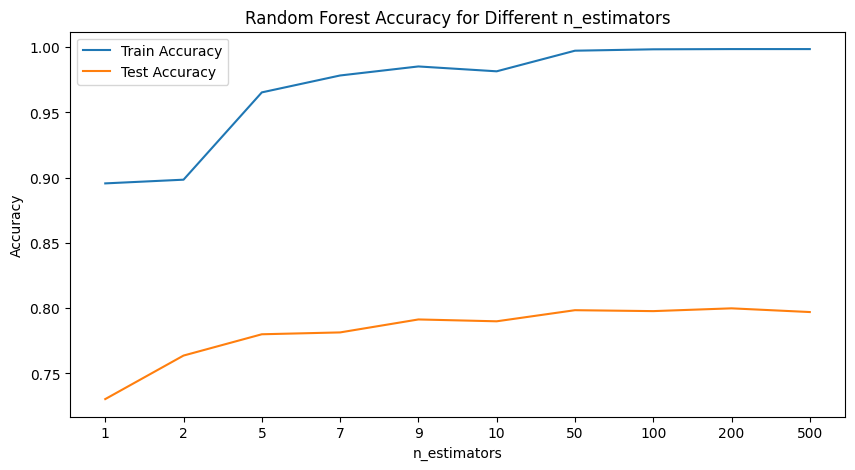

In [32]:
accuracy_train_list = []
accuracy_test_list = []
n_estimators_list = [1,2,5, 7, 9,10, 50, 100, 200, 500]
for n_estimators in n_estimators_list:
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_test = accuracy_score(y_test, y_test_pred)
    accuracy_train_list.append(accuracy_train)
    accuracy_test_list.append(accuracy_test)
    print(f"n_estimators: {n_estimators} => Train Accuracy: {accuracy_train:.4f}, Test Accuracy: {accuracy_test:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(accuracy_train_list, label='Train Accuracy')
plt.plot(accuracy_test_list, label='Test Accuracy')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy for Different n_estimators')
plt.legend()
plt.xticks(ticks=range(len(n_estimators_list)), labels=n_estimators_list)
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'min_samples_split': min_samples_split_list,
    'max_depth': max_depth_list,
    'n_estimators': n_estimators_list
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42, n_jobs=-1), param_grid=param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 200}


In [43]:
model = RandomForestClassifier(max_depth=8, n_estimators=200, min_samples_split=2, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
test_score = accuracy_score(y_test, y_test_pred)
train_score = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")

Train Accuracy: 0.8335, Test Accuracy: 0.8091


In [44]:
# Calculating F1 Score

f1, prec, recall = f1_score(y_train_pred, y_train)
print(f'f1: {f1}, precesion: {prec}, recall: {recall}')

f1, prec, recall = f1_score(y_test_pred, y_test)
print(f'f1: {f1}, precesion: {prec}, recall: {recall}')

f1: 0.6414373088685016, precesion: 0.7491071428571429, recall: 0.5608288770053476
f1: 0.5867895545314901, precesion: 0.6870503597122302, recall: 0.5120643431635389


Bad. But better than the single tree model.

Refinding the best hype params but with `class-weight`.

In [ ]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'), param_grid=param_grid, cv=3, n_jobs=-1,)
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")


Best Parameters: {'max_depth': 16, 'min_samples_split': 2, 'n_estimators': 500}


Different optimal hypeparams.

In [46]:
model = RandomForestClassifier(max_depth=16, n_estimators=500, min_samples_split=2, random_state=42, n_jobs=-1, class_weight='balanced')
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
test_score = accuracy_score(y_test, y_test_pred)
train_score = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")

f1, prec, recall = f1_score(y_train_pred, y_train)
print(f'Train set: f1: {f1}, precesion: {prec}, recall: {recall}')

f1, prec, recall = f1_score(y_test_pred, y_test)
print(f'Test set: f1: {f1}, precesion: {prec}, recall: {recall}')


Train Accuracy: 0.9858, Test Accuracy: 0.7956
Train set: f1: 0.973941368078176, precesion: 0.9498094027954257, recall: 0.9993315508021391
Test set: f1: 0.575221238938053, precesion: 0.639344262295082, recall: 0.5227882037533512


overfitting hella

In [47]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'), param_grid=param_grid, cv=3, n_jobs=-1, scoring='f1')
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")


Best Parameters: {'max_depth': 16, 'min_samples_split': 30, 'n_estimators': 500}


In [48]:
model = RandomForestClassifier(max_depth=16, n_estimators=500, min_samples_split=30, random_state=42, n_jobs=-1, class_weight='balanced')
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
test_score = accuracy_score(y_test, y_test_pred)
train_score = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")

f1, prec, recall = f1_score(y_train_pred, y_train)
print(f'Train set: f1: {f1}, precesion: {prec}, recall: {recall}')

f1, prec, recall = f1_score(y_test_pred, y_test)
print(f'Test set: f1: {f1}, precesion: {prec}, recall: {recall}')


Train Accuracy: 0.8115, Test Accuracy: 0.7835
Train set: f1: 0.7026875699888018, precesion: 0.6045279383429673, recall: 0.838903743315508
Test set: f1: 0.6607341490545049, precesion: 0.564638783269962, recall: 0.7962466487935657


In comparison to previous models, this one is catching more actual positives, but at the risk of more false positives.

Maybe improved with better dataset pre-processing?

I guess the decision of which to choose depends on the purpose of the model. 
I'm not sure how this can be of use, but if a company uses a churn predictor to take actions to keep customers (with discounts & offers maybe?), then if the keeping of a customer is worth more than the cost of a discount, then higher recall above is the better choice? 